In [234]:
import pandas as pd
df=pd.read_csv("laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [235]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [236]:
df.shape

(1303, 12)

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [238]:
df.drop(columns=["Unnamed: 0"], inplace=True)


In [239]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [240]:
df.isnull().sum() # 30 missing values are found

Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [241]:
df.isnull().sum().unique() # all missing values are in same rows

array([30])

In [242]:
df.dropna(inplace=True)

In [243]:
df.shape


(1273, 11)

In [244]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [245]:
df["Ram"] = df["Ram"].str.replace("GB", "") 
df["Ram"] = df["Ram"].astype("int32")

In [246]:

df["Ram"].dtype
df["Ram"].head()

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int32

In [247]:
df["Ram"].isnull().sum()


np.int64(0)

In [248]:
df["Weight"] = df["Weight"].str.replace("kg", "")


In [249]:
df["Weight"] = pd.to_numeric(df["Weight"], errors='coerce')

In [250]:
df["Weight"].dtype

dtype('float64')

In [251]:
df["Weight"].isnull().sum()


np.int64(1)

In [252]:
df.dropna(subset=["Weight"], inplace=True)

In [253]:
df["Price"].dtype

dtype('float64')

In [254]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1272 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1272 non-null   object 
 1   TypeName          1272 non-null   object 
 2   Inches            1272 non-null   object 
 3   ScreenResolution  1272 non-null   object 
 4   Cpu               1272 non-null   object 
 5   Ram               1272 non-null   int32  
 6   Memory            1272 non-null   object 
 7   Gpu               1272 non-null   object 
 8   OpSys             1272 non-null   object 
 9   Weight            1272 non-null   float64
 10  Price             1272 non-null   float64
dtypes: float64(2), int32(1), object(8)
memory usage: 114.3+ KB


<Axes: ylabel='Frequency'>

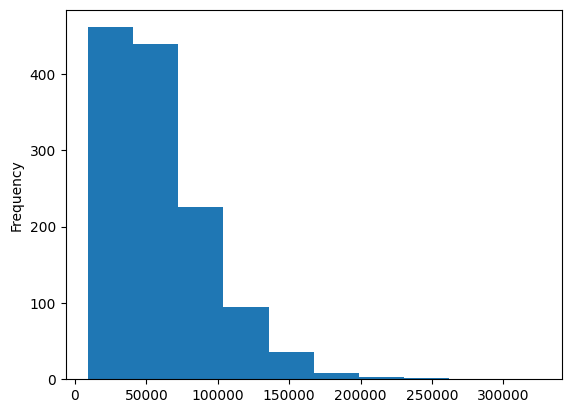

In [255]:
df["Price"].plot(kind="hist") # price distribution

In [256]:
df["Price"].median() # median is right choice because the price has outlier

np.float64(52107.84)

In [257]:
df["Price"].mean() # mean is affected by outliers, so median is more reliable

np.float64(59942.25518490566)

<Axes: >

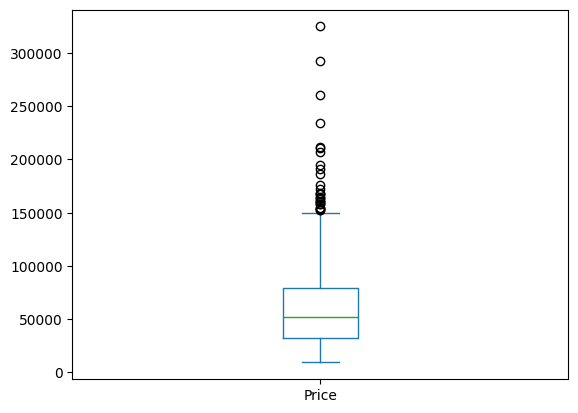

In [258]:
df["Price"].plot(kind="box") # boxplot is used to visualize spread and detect outliers 

<Axes: title={'center': 'Price'}, xlabel='Company'>

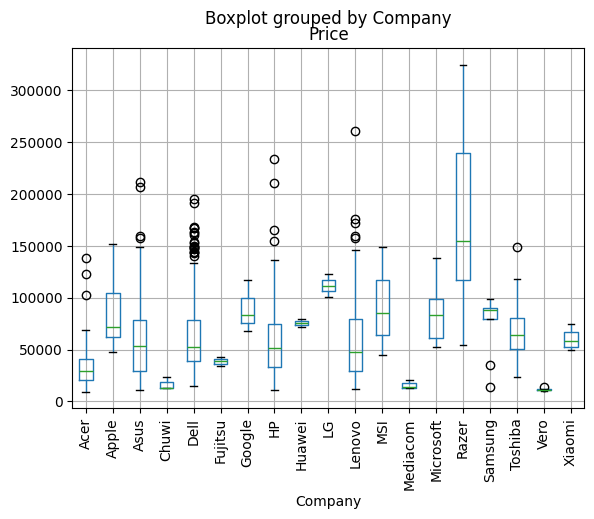

In [259]:
df.boxplot(column="Price", by="Company", rot=90)

In [260]:
df.groupby("Company")["Price"].mean().sort_values(ascending=False) # compare average price across companies

Company
Razer        178282.491429
LG           111834.720000
MSI           91814.548891
Google        89386.080000
Microsoft     85903.788000
Apple         83340.499886
Huawei        75870.720000
Samsung       75308.320000
Toshiba       66747.370213
Dell          63188.230103
Xiaomi        60390.882000
Asus          58972.373723
Lenovo        58072.477208
HP            57214.371465
Fujitsu       38574.720000
Acer          33394.615969
Chuwi         16745.726400
Mediacom      15717.600000
Vero          11584.404000
Name: Price, dtype: float64

In [261]:
df.groupby("Company")["Price"].mean().sort_values(ascending=True)

Company
Vero          11584.404000
Mediacom      15717.600000
Chuwi         16745.726400
Acer          33394.615969
Fujitsu       38574.720000
HP            57214.371465
Lenovo        58072.477208
Asus          58972.373723
Xiaomi        60390.882000
Dell          63188.230103
Toshiba       66747.370213
Samsung       75308.320000
Huawei        75870.720000
Apple         83340.499886
Microsoft     85903.788000
Google        89386.080000
MSI           91814.548891
LG           111834.720000
Razer        178282.491429
Name: Price, dtype: float64

In [262]:
df.groupby("Ram")["Price"].mean() # Analyze how RAM affects price, 1GB shows anomaly due to very few samples

Ram
1      53226.720000
2      14756.743636
4      30552.912235
6      32826.420720
8      63137.384304
12     66037.277952
16    103158.266994
24    117553.440000
32    181849.215812
64    117511.526400
Name: Price, dtype: float64

In [263]:
df["Ram"].value_counts() # 8GB RAM is most common configuration 

Ram
8     600
4     367
16    194
6      40
12     25
2      22
32     17
64      3
24      3
1       1
Name: count, dtype: int64

<Axes: xlabel='Ram'>

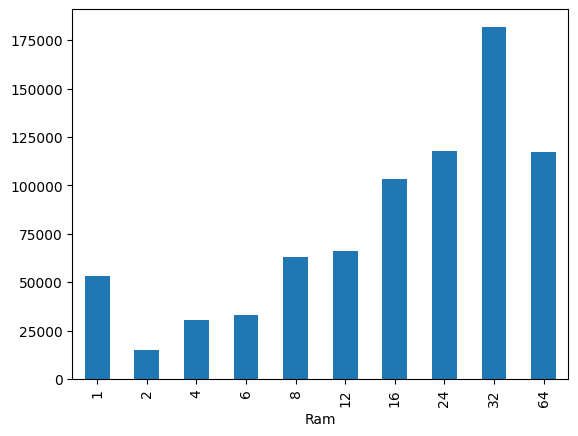

In [264]:
df.groupby("Ram")["Price"].mean().plot(kind="bar")

<Axes: xlabel='Weight', ylabel='Price'>

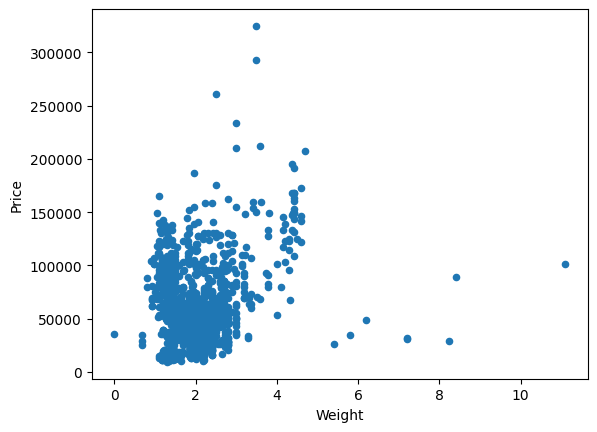

In [265]:
df.plot.scatter(x="Weight", y="Price") # finding relationship between weight and price

In [266]:
df.groupby("TypeName")["Price"].mean().sort_values(ascending=False) # compare average price across laptop types

TypeName
Workstation           121497.525683
Gaming                 92204.328662
Ultrabook              82956.160800
2 in 1 Convertible     68186.738110
Notebook               41545.173052
Netbook                34884.858000
Name: Price, dtype: float64

In [267]:
df.corr(numeric_only=True) # measure strength of relationship between features and price

,Ram,Weight,Price
Ram,1.000000,0.283302,0.685737
Weight,0.283302,1.000000,0.175928
Price,0.685737,0.175928,1.000000
